C:\Users\Jakob\AppData\Local\Temp\ipykernel_12920\2367082265.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k_pol[ik] = root


0 0.7315907189792292
1 0.5817624332633997
2 0.19033188634263665
3 0.03551759038514124
4 0.005218502522778001
5 0.003427658995859506
6 0.00262398553800125
7 0.001670611091602936
8 0.0009600109531215928
9 0.0005291783552872076
10 0.00028566179517808266
11 0.00015249729195021544
12 8.091091500528336e-05
13 4.2820824829092885e-05
14 2.2625266244968856e-05
15 1.1940698998902377e-05
16 6.297265214616488e-06
17 3.319667338352872e-06
18 1.7495906017295226e-06
19 9.219810617189239e-07


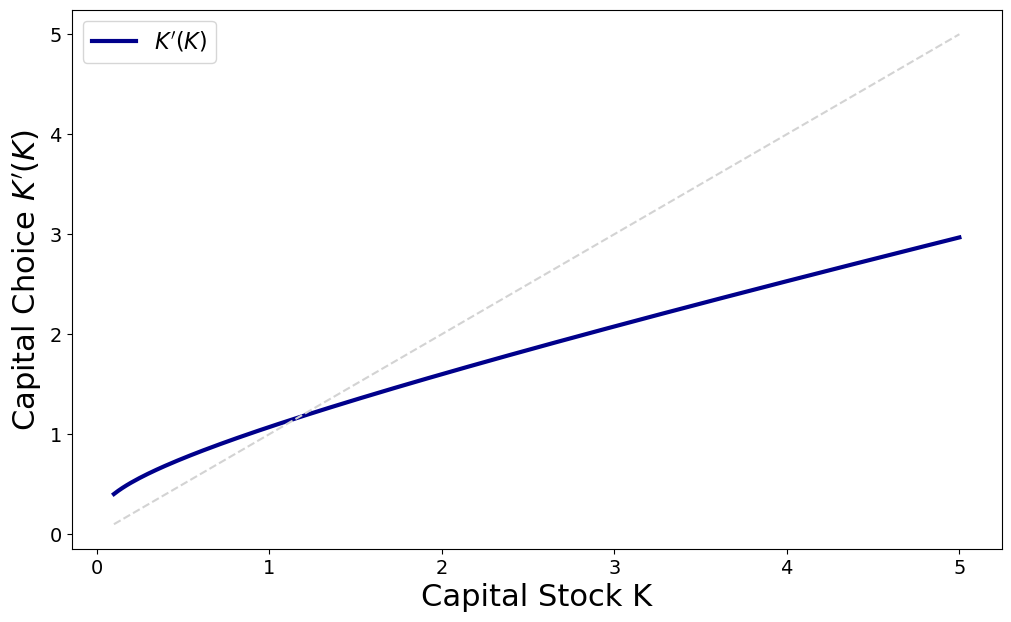

In [1]:
import numpy as np
from scipy import interpolate, optimize
import matplotlib.pyplot as plt

# Economic parameters
betta = 0.95
alpha = 0.3
delta = 0.1
gamma = 0.25
tau = 0.1
lamb = 0.0

# Grid parameters
k_min = 0.1
k_max = 5.0
nk = 200

# Technical parameters
maxiter = 10000
tol = 1e-6

# Initialization
kgrid = np.linspace(k_min,k_max,nk)
k_guess = np.zeros(nk)
k_guess[:] = (1-delta)*kgrid

# RHS of the Euler Equation for given k and a guess for k'
def sys_of_eqs(kp, k):
    kpp_interp = interpolate.interp1d(kgrid, k_guess, kind='linear', fill_value='extrapolate')
    kpp = kpp_interp(kp)

    T = lamb * tau * (k ** alpha + (1 - delta) * k)
    Tp = lamb * tau * (kp ** alpha + (1 - delta) * kp)

    c = (1 - tau) * (k ** alpha + (1.0 - delta) * k) - kp + T
    cp = (1 - tau) * (kp ** alpha + (1.0 - delta) * kp) - kpp + Tp

    ee_res = 1.0 - betta * (1 - tau) * (cp / c) ** (-gamma) * (alpha * kp ** (alpha - 1.0) + 1.0 - delta)

    return ee_res

# Main loop
k_pol = np.zeros(nk)

for iter0 in range(maxiter):

    for ik in range(nk):
        root = optimize.fsolve(sys_of_eqs, k_guess[ik], args=kgrid[ik])
        k_pol[ik] = root

    metric = np.amax(np.abs(k_pol - k_guess))
    print(iter0, metric)
    if (metric < tol):
        break

    k_guess[:] = k_pol

fig,ax=plt.subplots(figsize=(12,7))
ax.plot(kgrid,k_pol[:],color="darkblue",linewidth=3,label="$K'(K)$")
ax.plot(kgrid, kgrid, color='lightgrey', linestyle='dashed')

ax.set_ylabel("Capital Choice $K'(K)$", fontsize=22)
ax.set_xlabel("Capital Stock K", fontsize=22)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

plt.legend(fontsize= 16, loc='upper left')
plt.show()